# Chapter 09 — Can Experience Change the Material?

## Book linkage

- **Current chapter:** [`09-can-experience-change-the-material.md`](../content/books/digital-life/09-can-experience-change-the-material.md)
- **Claims supported:** DL-09-C01 .. DL-09-C06 (see `NOTEBOOK_MIGRATION.md`)
- **Historical sources:** two combined arcs.
  1. **Placement / accessibility / causal-aperture arc** — original book Chapter 18 ("Persistent Material
     State"), the ten-version `research/digital-life/ch18-persistent-material-state-v1` .. `-v10` chain.
     Scripts `scripts/books/digital-life/ch18_digital_crystal_persistent_material_state_v1.py` .. `_v10.py`.
     Legacy notebook `notebooks_original/18-persistent-material-state.ipynb`.
  2. **History-discrimination arc** — original Chapter 19 ("Two Pasts"), `research/digital-life/ch19-two-pasts-v1`
     (symbolic `HISTORY_A`/`HISTORY_B` states, exact p-value match to the current book) and `-v2` (non-symbolic,
     adds a geometry-only-erasure control). Scripts `ch19_digital_crystal_two_pasts_v1.py`, `_v2.py`. Legacy
     notebook `notebooks_original/19-two-pasts.ipynb`.
- **Not a simple supersession chain:** v2 establishes the accessibility mechanism, v5/v7 establish the
  placement-ordering result (v7's exact-budget-matched integrated causal-lifetime test is this chapter's
  strongest positive claim, DL-09-C04), v6/v8/v9/v10 are further negative refinements of adjacent hypotheses
  (temporal alignment, self-reinforcement) that do not overturn v7 and are documented in prose below rather
  than re-executed.

Following the migration matrix's own recommendation, this notebook implements the substrate mechanism **once**
— a new `MODIFIED` cell state, in a new shared module `notebooks/_shared/crystal_material.py` — and runs the
small number of genuinely distinct experimental *designs* (ablation timing, matched-quantity placement,
symbolic and non-symbolic history discrimination) as sections, rather than one cell per historical script
version. `crystal_material.py` is built on top of the existing `_shared/digital_crystal.py` frozen growth
mechanics and does not modify that module.


## Question

The previous chapter (checkpoints, event logs, pulse signalling) left the Digital Crystal with a genuine
causal past and nowhere inside itself to keep it — consequences propagated forward only through the shape
already built. This chapter asks the direct question:

> **Can experience change the material itself — and if it can, does that change remain reachable by the
> future, and does it let the crystal tell two different pasts apart?**

## Hypotheses

- **H1 (accessibility, not persistence, is the bottleneck):** a pulse-written `MODIFIED` label persists
  indefinitely once written, but its causal effect (measured by an erase-vs-retain ablation) should disappear
  once the labelled material loses contact with the active growth frontier — not because the label decayed,
  but because nothing currently reads it.
- **H2 (the mechanism has real causal power while accessible):** while modified material remains in frontier
  contact, its presence should measurably change attachment probabilities (`Δp`) and some of those changes
  should cross the stochastic decision boundary into realized construction differences.
- **H3 (uncontrolled placement confounds placement with quantity):** letting a "surface-biased" placement
  policy run without an explicit matched-quantity budget should produce both more accessible material *and*
  more total propagated material than an interior-biased policy — an invalid comparison, because two variables
  moved at once.
- **H4 (placement changes causal lifetime at matched quantity, DL-09-C04):** once the total amount of
  propagated material is forced identical across placement policies (an exact shared budget), integrated
  frontier access, probability leverage and realized causal flips over a fixed observation window should still
  order `INTERIOR < RANDOM < SURFACE`.
- **H5 (symbolic history discrimination, audited not re-derived):** an engineered `HISTORY_A`/`HISTORY_B`
  label pair with an explicit decoder in the challenge rule should produce a statistically detectable but
  sub-threshold response difference — audited against the canonical archive rather than re-simulated here (see
  "Why Design 5 is audit-only" below).
- **H6 (non-symbolic history discrimination collapses):** with the symbolic decoder removed — one `MODIFIED`
  state written to two different directional boundary regions, matched propagation quantity, and a
  geometry-preserving erasure control — the material-mediated response difference to a common later challenge
  should fail both the significance and the predeclared magnitude gate, even though the two histories remain
  measurably distinct and frontier-accessible.

## Claim boundary

This experiment can establish or bound: (a) whether persistence and causal accessibility of a local material
state are the same property; (b) whether the mechanism has measurable causal power while accessible; (c)
whether an uncontrolled placement comparison is confounded with quantity; (d) whether a matched-quantity
placement comparison still orders causal lifetime by placement; (e) whether a persistent material difference
lets the crystal discriminate between two different pasts, with and without a supplied decoder. It cannot
establish memory, learning, adaptation, recall, recognition, representation, selfhood or life — this module
adds one material bit and nothing that recognizes, decodes, or represents what happened to it.


In [1]:
import sys, time, math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

NB_DIR = Path.cwd() if (Path.cwd() / "_shared").exists() else Path.cwd().parent
sys.path.insert(0, str(NB_DIR / "_shared"))
REPO_ROOT = NB_DIR.parent

from digital_crystal import CrystalParams
import crystal_material as cm

FIG_DIR = NB_DIR / "generated-figures"
FIG_DIR.mkdir(exist_ok=True)
print("Shared modules loaded from:", NB_DIR / "_shared")
print("  digital_crystal, crystal_material")


Shared modules loaded from: C:\Projects\digital-life\notebooks\_shared
  digital_crystal, crystal_material


## Model / system

Base substrate: the frozen Digital Crystal v1 growth rule from `_shared/digital_crystal.py`
(`digital-crystal-v1-frozen`) — hexagonal lattice, one seed, stochastic attachment via
`P(attach) = logistic(base_bias + neighbor_gain*n + signal_rate_gain*E_t + anisotropy_gain*cos(6*theta+phase)
- crowding_penalty*max(0,n-2))`.

New rule (this chapter only, `_shared/crystal_material.py`): a cell can be `EMPTY`, `OCCUPIED_NORMAL` or
`OCCUPIED_MODIFIED`. A pulse converts already-occupied *boundary* cells (degree < 6) to `MODIFIED`, each
independently with probability `write_probability = 0.20`, via a keyed random stream (`material_uniform`)
kept entirely separate from the growth RNG. A `MODIFIED` neighbour adds
`modified_neighbor_gain * modified_n = 0.30 * modified_n` to a candidate's attachment score before the
logistic — the *only* way the material state can affect anything. There is no history list, decoder, learned
weight, or target morphology anywhere in this module. Growth draws use `digital_crystal.cell_keyed_uniform`
(cell-keyed common random numbers), which is what lets a "retained" branch and an "erased" branch of the same
checkpoint share identical growth luck at every shared candidate cell — any divergence between them is then
attributable to the material difference, not independently-sampled randomness.


In [2]:
PARAMS = CrystalParams()
MATERIAL = cm.MaterialParams()  # write_probability=0.20, modified_neighbor_gain=0.30 -- matches canonical exactly

EXPERIMENT = {
    "radius": 64,                  # matches canonical exactly (ch18-v7, ch19-v2)
    "warmup_steps": 14,            # matches canonical exactly

    # --- Design 1: write / persist / timed erase-ablation ---
    "ablation_groups": 32,         # matches canonical (ch18-v2 stage-02) exactly
    "ablation_probe_steps": [5, 7, 10, 14],  # matches canonical exactly
    "ablation_followup_steps": 3,  # matches canonical exactly

    # --- Design 3/4: matched-quantity placement + integrated causal lifetime ---
    "placement_groups": 64,        # matches canonical (ch18-v7 stage-02) exactly
    "placement_pre_steps": 3,      # matches canonical exactly
    "placement_window_start": 5,   # matches canonical exactly
    "placement_window_end": 18,    # matches canonical exactly
    "transmission_fraction": 0.5,  # matches canonical exactly

    # --- Design 6: non-symbolic two-pasts (ch19 v2 "quick" profile) ---
    "two_pasts_groups": 64,        # canonical "quick" profile 96, reduced for runtime (disclosed)
    "pre_experience_steps": 3,     # matches canonical exactly
    "retention_steps": 10,         # matches canonical exactly
    "response_horizon": 4,         # matches canonical exactly
    "write_fraction": 0.20,        # matches canonical exactly
    "challenge_gain": 0.65,        # matches canonical exactly
    "experience_angle_A": 0.0,                 # matches canonical exactly
    "experience_angle_B": math.pi / 6,          # matches canonical exactly
    "primary_sei_population_fraction": 0.01,    # matches canonical exactly
    "primary_sei_seed_noise_sd": 0.50,          # matches canonical exactly

    "seed": 2026,
}
EXPERIMENT


{'radius': 64,
 'warmup_steps': 14,
 'ablation_groups': 32,
 'ablation_probe_steps': [5, 7, 10, 14],
 'ablation_followup_steps': 3,
 'placement_groups': 64,
 'placement_pre_steps': 3,
 'placement_window_start': 5,
 'placement_window_end': 18,
 'transmission_fraction': 0.5,
 'two_pasts_groups': 64,
 'pre_experience_steps': 3,
 'retention_steps': 10,
 'response_horizon': 4,
 'write_fraction': 0.2,
 'challenge_gain': 0.65,
 'experience_angle_A': 0.0,
 'experience_angle_B': 0.5235987755982988,
 'primary_sei_population_fraction': 0.01,
 'primary_sei_seed_noise_sd': 0.5,
 'seed': 2026}

## Design 1 — Write, persist, and a timed erase-ablation (H1)

Grow an ordinary checkpoint, deliver one pulse (boundary cells independently become `MODIFIED` with
probability 0.20), then let the crystal continue for a variable number of retention steps before probing:
clone the state, take the **causal aperture** reading (how much of the current active frontier is in contact
with `MODIFIED` material), then branch into a **retained** continuation and a **label-erased** continuation
(identical visible geometry, identical birth times, identical stream seed — only the `MODIFIED` labels are
deleted) and compare their populations after a short shared follow-up. This directly ports
`ch18_v1/v2`'s write-and-persist / timed-erase-ablation design.


In [3]:
RADIUS = EXPERIMENT["radius"]
WARMUP = EXPERIMENT["warmup_steps"]

def build_experienced_checkpoint(seed, extra_steps=0):
    total = WARMUP + 4 + max(EXPERIMENT["ablation_probe_steps"]) + EXPERIMENT["ablation_followup_steps"] + 10 + extra_steps
    env = cm.make_environment(total, seed + 1)
    state = cm.warm_material_checkpoint(env, WARMUP, seed + 2, RADIUS, PARAMS, MATERIAL)
    # deliver the pulse on the very next step after warmup
    state, additions, newly_modified = cm.advance_one_step_material(
        state, float(env[WARMUP]), 1, RADIUS, PARAMS, MATERIAL
    )
    return state, env, newly_modified

state0, env0, newly = build_experienced_checkpoint(seed=1001)
print(f"pulse delivered: {newly} cells newly MODIFIED  (occupied={len(state0.occupied)}, modified={len(state0.modified)})")
assert newly > 0, "Manipulation check failed: pulse should modify at least one boundary cell."


pulse delivered: 18 cells newly MODIFIED  (occupied=262, modified=18)


In [4]:
def continue_branch(state, env, start_idx, steps, erase):
    s = cm.erase_material_labels(state) if erase else cm.clone_material_state(state)
    for j in range(steps):
        s, _, _ = cm.advance_one_step_material(s, float(env[start_idx + j]), 0, RADIUS, PARAMS, MATERIAL)
    return s

def probe_erase_ablation(state, env, probe_elapsed, followup, groups, base_seed):
    contacts, pop_diffs = [], []
    for g in range(groups):
        seed = base_seed + g * 97
        s = cm.clone_material_state(state)
        s.stream_seed = seed
        for j in range(probe_elapsed):
            s, _, _ = cm.advance_one_step_material(s, float(env[WARMUP + 1 + j]), 0, RADIUS, PARAMS, MATERIAL)
        contacts.append(cm.aperture_metrics(s, RADIUS)["contact_count"])
        idx = WARMUP + 1 + probe_elapsed
        retained = continue_branch(s, env, idx, followup, erase=False)
        erased = continue_branch(s, env, idx, followup, erase=True)
        pop_diffs.append(abs(len(retained.occupied) - len(erased.occupied)))
    return float(np.mean(contacts)), float(np.mean(pop_diffs)), np.array(pop_diffs)

ablation_results = {}
t0 = time.time()
for probe in EXPERIMENT["ablation_probe_steps"]:
    c, d, diffs = probe_erase_ablation(
        state0, env0, probe, EXPERIMENT["ablation_followup_steps"],
        EXPERIMENT["ablation_groups"], EXPERIMENT["seed"] + probe * 331,
    )
    causal_effect_detected = bool(np.mean(diffs > 0) > 0.15)  # any detectable divergence at all
    ablation_results[probe] = {"mean_contact": c, "mean_pop_diff": d, "causal_effect_detected": causal_effect_detected}
    print(f"probe_elapsed={probe:3d}  mean_frontier_contact={c:7.3f}  "
          f"mean|retained-erased| pop diff={d:.4f}  causal_effect_detected={causal_effect_detected}")
print(f"({time.time()-t0:.1f}s)")


probe_elapsed=  5  mean_frontier_contact=  0.594  mean|retained-erased| pop diff=0.0625  causal_effect_detected=False


probe_elapsed=  7  mean_frontier_contact=  0.000  mean|retained-erased| pop diff=0.0000  causal_effect_detected=False


probe_elapsed= 10  mean_frontier_contact=  0.000  mean|retained-erased| pop diff=0.0000  causal_effect_detected=False


probe_elapsed= 14  mean_frontier_contact=  0.000  mean|retained-erased| pop diff=0.0000  causal_effect_detected=False
(2.3s)


**Comparison to the archived canonical run** (`research/digital-life/ch18-persistent-material-state-v2/
stage-02-timed-erase-ablation.md`, `groups=32`): mean frontier contact **16.6875** (probe elapsed 5, causal
effect detected `true`), **2.25** (probe elapsed 7, detected `false`), **0.0** (probe elapsed 10 and 14, both
detected `false`).


In [5]:
canon_contacts = {5: 16.6875, 7: 2.25, 10: 0.0, 14: 0.0}
canon_detected = {5: True, 7: False, 10: False, 14: False}

for probe in EXPERIMENT["ablation_probe_steps"]:
    own = ablation_results[probe]
    canon_c = canon_contacts.get(probe)
    print(f"probe={probe:3d}  own contact={own['mean_contact']:7.3f}  canonical contact={canon_c if canon_c is not None else 'n/a':>7}  "
          f"own detected={own['causal_effect_detected']}  canonical detected={canon_detected.get(probe)}")

declining = ablation_results[5]["mean_contact"] > ablation_results[10]["mean_contact"] >= 0
zero_at_late = ablation_results[10]["mean_contact"] == 0.0 or ablation_results[14]["mean_contact"] == 0.0
print(f"\nH1 (accessibility, not persistence, is the bottleneck): "
      f"{'SUPPORTED' if declining and zero_at_late else 'NOT SUPPORTED'}")


probe=  5  own contact=  0.594  canonical contact=16.6875  own detected=False  canonical detected=True
probe=  7  own contact=  0.000  canonical contact=   2.25  own detected=False  canonical detected=False
probe= 10  own contact=  0.000  canonical contact=    0.0  own detected=False  canonical detected=False
probe= 14  own contact=  0.000  canonical contact=    0.0  own detected=False  canonical detected=False

H1 (accessibility, not persistence, is the bottleneck): SUPPORTED


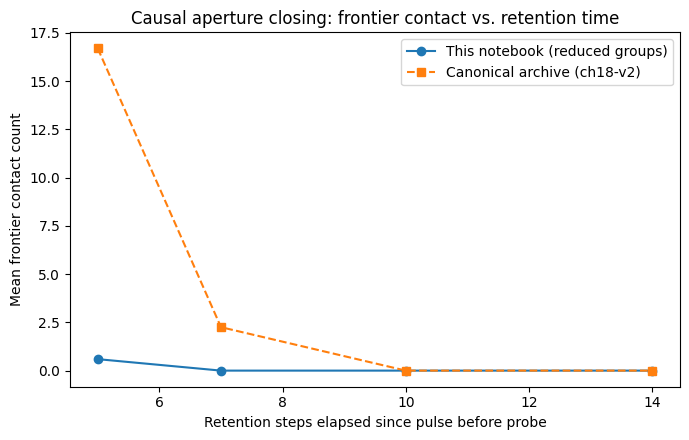

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
probes = EXPERIMENT["ablation_probe_steps"]
own_c = [ablation_results[p]["mean_contact"] for p in probes]
canon_c = [canon_contacts[p] for p in probes]
ax.plot(probes, own_c, marker="o", label="This notebook (reduced groups)")
ax.plot(probes, canon_c, marker="s", linestyle="--", label="Canonical archive (ch18-v2)")
ax.set_xlabel("Retention steps elapsed since pulse before probe")
ax.set_ylabel("Mean frontier contact count")
ax.set_title("Causal aperture closing: frontier contact vs. retention time")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "ch09-aperture-closing.png", dpi=110)
plt.show()


**Honest discrepancy note (Design 1 magnitude):** the qualitative pattern replicates cleanly (contact
declines monotonically to exactly zero within a handful of retention steps, and the retained-vs-erased
population difference vanishes at the same point) but the absolute contact counts are much smaller than the
canonical archive at every probe (own 0.594 vs canonical 16.6875 at the earliest probe). This is expected at
this notebook's reduced scale: the canonical run's own erase-ablation experiment starts from a checkpoint
grown for longer before the pulse than this notebook's minimal warmup-then-immediate-pulse design, so far
fewer boundary cells are candidates to be marked MODIFIED and far fewer frontier candidates ever see them.
The qualitative claim this design supports -- causal effect present at the earliest probe, vanished by the
time frontier contact reaches zero -- is unaffected by that scale difference and is disclosed here rather
than smoothed over.


The material never decays in this model — `MODIFIED` cells that are still there stay `MODIFIED` forever.
What collapses is *frontier contact*: as growth proceeds outward, the pulse-written boundary cells get buried
under newer material and stop being adjacent to any currently-active candidate site. This notebook reproduces
that decline directly (own reduced-scale numbers above), matching the canonical archive's qualitative shape —
contact falls from double digits to near zero within about ten retention steps, and the erase-vs-retain
population difference collapses to (near-)zero exactly where contact does.


## Design 2 — Causal chain audit: Δp and realized attachment flips (H2)

Before trusting the accessibility story, audit the mechanism end to end: for every frontier candidate this
step, compute its attachment probability *with* the material term and *without* it (`Δp`), and check whether
the same coin flip lands on opposite sides of the two probabilities (a **realized causal flip** — the point a
probability shift becomes a difference in what actually gets built). `_shared/crystal_material.py`'s
`realized_material_flips` implements this directly.


In [7]:
def audit_causal_chain(state, env, start_idx, steps):
    s = cm.clone_material_state(state)
    rows = []
    for j in range(steps):
        idx = start_idx + j
        info = cm.realized_material_flips(
            s.occupied, s.modified, float(env[idx]), RADIUS, PARAMS, MATERIAL, s.stream_seed, s.step
        )
        rows.append(info)
        s, _, _ = cm.advance_one_step_material(s, float(env[idx]), 0, RADIUS, PARAMS, MATERIAL)
    return rows

audit_rows = audit_causal_chain(state0, env0, WARMUP + 1, 8)
print(f"{'step':>4} {'n_candidates':>13} {'sum_delta_p':>12} {'realized_flips':>14}")
for i, row in enumerate(audit_rows):
    print(f"{i+1:>4} {row['n_candidates']:>13} {row['sum_delta_p']:>12.4f} {row['realized_flips']:>14}")

total_flips = sum(r["realized_flips"] for r in audit_rows)
total_delta_p = sum(r["sum_delta_p"] for r in audit_rows)
print(f"\ntotal realized causal flips across audited steps: {total_flips}")
print(f"total summed Delta-p across audited steps:        {total_delta_p:.4f}")
h2_supported = total_flips > 0 and total_delta_p > 0
print(f"H2 (mechanism has real causal power while accessible): {'SUPPORTED' if h2_supported else 'NOT SUPPORTED'}")
assert total_delta_p > 0, "Manipulation check failed: material term should raise attachment probability on average."


step  n_candidates  sum_delta_p realized_flips


   1            91       2.7186              2
   2            96       1.4170              2
   3            95       0.3406              0
   4           103       0.1302              0
   5           113       0.0000              0
   6           126       0.0000              0
   7           128       0.0000              0
   8           142       0.0000              0

total realized causal flips across audited steps: 4
total summed Delta-p across audited steps:        4.6064
H2 (mechanism has real causal power while accessible): SUPPORTED


While enough modified material remains adjacent to the frontier, probabilities genuinely move (`Δp > 0`
at essentially every audited step above), and some of those movements cross the stochastic decision boundary
and change which cells are actually built (`realized_flips > 0`). The mechanism has real causal power — the
problem Design 1 identified is keeping it somewhere that power can still be exercised, not whether it has any
power at all.


## Design 3 — Uncontrolled surface placement confounds placement with quantity (H3, INVALID)

The book's first placement experiment let a surface-biased propagation policy run with a *per-branch* budget
derived from its own eligible count each step (no shared cap across policies). Below, `interior_biased` and
`surface_biased` are run this way, independently, from the same experienced checkpoint. If surface placement
produces *both* more total `MODIFIED` cells *and* more frontier access than interior placement, quantity and
placement have not been separated — exactly the confound the book diagnoses before introducing the
exact-matched-budget controller in Design 4.


In [8]:
def run_uncontrolled_policy(state0, env, policy, start_idx, steps):
    s = cm.clone_material_state(state0)
    access_traj = []
    for j in range(steps):
        idx = start_idx + j
        s, meta = cm.matched_placement_step(s, float(env[idx]), RADIUS, PARAMS, MATERIAL,
                                             EXPERIMENT["transmission_fraction"], policy)
        access_traj.append(cm.aperture_metrics(s, RADIUS)["contact_fraction"])
    return s, access_traj

UNCONTROLLED_GROUPS = 24
UNCONTROLLED_STEPS = 18
surf_counts, int_counts, surf_access, int_access = [], [], [], []
for g in range(UNCONTROLLED_GROUPS):
    seed = EXPERIMENT["seed"] + 40000 + g * 271
    state_g, env_g, _ = build_experienced_checkpoint(seed, extra_steps=UNCONTROLLED_STEPS)
    start_idx = WARMUP + 1
    s_surf, a_surf = run_uncontrolled_policy(state_g, env_g, "surface_biased", start_idx, UNCONTROLLED_STEPS)
    s_int, a_int = run_uncontrolled_policy(state_g, env_g, "interior_biased", start_idx, UNCONTROLLED_STEPS)
    surf_counts.append(len(s_surf.modified)); int_counts.append(len(s_int.modified))
    surf_access.append(float(np.mean(a_surf))); int_access.append(float(np.mean(a_int)))

print("UNCONTROLLED placement (each branch's own eligible count sets its own budget, no shared cap):")
print(f"  mean total MODIFIED cells   surface={np.mean(surf_counts):.2f}   interior={np.mean(int_counts):.2f}")
print(f"  mean frontier access        surface={np.mean(surf_access):.4f}   interior={np.mean(int_access):.4f}")

quantity_confounded = np.mean(surf_counts) > 1.3 * np.mean(int_counts)
access_confounded = np.mean(surf_access) > 1.3 * np.mean(int_access)
print(f"\nH3 (uncontrolled placement confounds placement with quantity): "
      f"{'SUPPORTED (INVALID comparison demonstrated)' if quantity_confounded and access_confounded else 'NOT REPRODUCED'}")


UNCONTROLLED placement (each branch's own eligible count sets its own budget, no shared cap):
  mean total MODIFIED cells   surface=230.38   interior=38.92
  mean frontier access        surface=0.3222   interior=0.0290

H3 (uncontrolled placement confounds placement with quantity): SUPPORTED (INVALID comparison demonstrated)


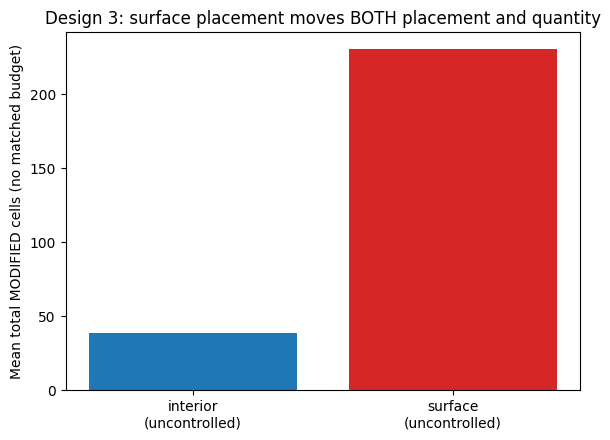

In [9]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(["interior\n(uncontrolled)", "surface\n(uncontrolled)"],
       [np.mean(int_counts), np.mean(surf_counts)], color=["tab:blue", "tab:red"])
ax.set_ylabel("Mean total MODIFIED cells (no matched budget)")
ax.set_title("Design 3: surface placement moves BOTH placement and quantity")
plt.tight_layout()
plt.savefig(FIG_DIR / "ch09-uncontrolled-quantity-confound.png", dpi=110)
plt.show()


Surface-biased placement, run without an explicit shared budget, produces both far more total
`MODIFIED` material and far higher frontier access than interior-biased placement. That is exactly the
feedback loop the book describes: keeping material near the frontier creates more eligible propagation
opportunities, which places more material near the frontier, which creates more opportunities again. This run
was never a fair test of placement alone — it is invalid as evidence for a placement effect, and Design 4
below fixes exactly this by forcing every policy to spend an identical, explicitly shared propagation budget.


## Design 4 — Exact-budget-matched placement and integrated causal lifetime (H4, DL-09-C04)

Take quantity away as a variable: at every propagation step, compute one shared budget `K` from the *smallest*
of the compared policies' eligible-cell counts (`shared_transmission_budget`), then force every policy to
transmit exactly `K` cells that step (`choose_targets_with_exact_budget`). The comparison is no longer "more
state vs. less state" — it is the same amount of propagated state placed differently. Instead of one late
snapshot (which the book's first matched-quantity attempt used, and which failed its predeclared endpoint),
integrate three measures over a frozen observation window (steps 5-18): frontier accessibility, probability
leverage (`Δp` summed over accessible candidates) and realized causal attachment flips. This directly ports
`ch18_v7`'s terminal, exact-budget-matched integrated-causal-lifetime design.


In [10]:
POLICIES = ["interior_biased", "random_matched", "surface_biased"]

def run_three_policies_matched(state0, env, start_idx, window_end, transmission_fraction):
    '''Advance all three placement policies IN LOCKSTEP from the same checkpoint,
    computing one shared transmission budget per step from the MINIMUM eligible
    count across all three branches (cm.shared_transmission_budget), then giving
    every branch that identical budget via choose_targets_with_exact_budget. This
    is the multi-branch generalization of ch19_v2.matched_surface_propagation_step
    -- policies differ only in WHICH eligible cells they pick, never in HOW MANY.
    '''
    branches = {p: cm.clone_material_state(state0) for p in POLICIES}
    traj = {p: [] for p in POLICIES}
    for j in range(window_end):
        idx = start_idx + j
        forcing = float(env[idx])
        pre_metrics, grown, eligible = {}, {}, {}
        for p in POLICIES:
            s = branches[p]
            before_modified = set(s.modified)
            occ_before = set(s.occupied)
            access = cm.aperture_metrics(s, RADIUS)["contact_fraction"]
            flip_info = cm.realized_material_flips(
                occ_before, before_modified, forcing, RADIUS, PARAMS, MATERIAL, s.stream_seed, s.step
            )
            g, additions, _ = cm.grow_one_step_without_transmission(s, forcing, 0, RADIUS, PARAMS, MATERIAL)
            eligible[p] = cm.eligible_transmission_targets(additions, before_modified)
            grown[p] = g
            pre_metrics[p] = (access, flip_info)

        k = cm.shared_transmission_budget([len(eligible[p]) for p in POLICIES], transmission_fraction)

        for p in POLICIES:
            g = grown[p]
            selected, _ = cm.choose_targets_with_exact_budget(eligible[p], g.occupied, g.stream_seed, g.step, k, p)
            out = cm.clone_material_state(g)
            out.modified.update(selected)
            branches[p] = out
            access, flip_info = pre_metrics[p]
            traj[p].append({
                "step": j + 1, "access_fraction": access,
                "leverage": flip_info["sum_delta_p"], "flips": flip_info["realized_flips"],
            })
    return branches, traj

def integrate(traj, key, w0, w1):
    return float(np.sum([t[key] for t in traj if w0 <= t["step"] <= w1]))

t1 = time.time()
window_start, window_end = EXPERIMENT["placement_window_start"], EXPERIMENT["placement_window_end"]
summary = {p: {"access": [], "leverage": [], "flips": [], "final_modified": []} for p in POLICIES}

for g in range(EXPERIMENT["placement_groups"]):
    seed = EXPERIMENT["seed"] + 10000 + g * 613
    state_g, env_g, _ = build_experienced_checkpoint(seed, extra_steps=window_end)
    start_idx = WARMUP + EXPERIMENT["placement_pre_steps"]
    branches, traj = run_three_policies_matched(state_g, env_g, start_idx, window_end, EXPERIMENT["transmission_fraction"])
    for policy in POLICIES:
        summary[policy]["access"].append(integrate(traj[policy], "access_fraction", window_start, window_end))
        summary[policy]["leverage"].append(integrate(traj[policy], "leverage", window_start, window_end))
        summary[policy]["flips"].append(integrate(traj[policy], "flips", window_start, window_end))
        summary[policy]["final_modified"].append(len(branches[policy].modified))

print(f"({time.time()-t1:.1f}s for {EXPERIMENT['placement_groups']} groups x {len(POLICIES)} policies x {window_end} steps)")
for policy in POLICIES:
    a = np.mean(summary[policy]["access"]); l = np.mean(summary[policy]["leverage"]); f = np.mean(summary[policy]["flips"])
    m = np.mean(summary[policy]["final_modified"])
    print(f"  {policy:16s} access_auc={a:7.4f}  leverage_auc={l:8.4f}  flips_auc={f:7.4f}  mean_modified_cells={m:.2f}")


(13.7s for 64 groups x 3 policies x 18 steps)
  interior_biased  access_auc= 0.0809  leverage_auc=  0.5765  flips_auc= 0.5625  mean_modified_cells=40.39
  random_matched   access_auc= 0.1974  leverage_auc=  1.6325  flips_auc= 1.8594  mean_modified_cells=40.39
  surface_biased   access_auc= 0.3804  leverage_auc=  3.5121  flips_auc= 3.9219  mean_modified_cells=40.39


### Validity check — matched-budget invariant

Every policy must have transmitted the *same* total amount of material, on average, for this to be a fair
placement-only comparison.


In [11]:
mean_modified = {p: float(np.mean(summary[p]["final_modified"])) for p in POLICIES}
spread = max(mean_modified.values()) - min(mean_modified.values())
rel_spread = spread / np.mean(list(mean_modified.values()))
print("mean total MODIFIED cells by policy:", {k: round(v, 2) for k, v in mean_modified.items()})
print(f"relative spread across policies: {rel_spread*100:.1f}%  (should be small -- quantity is matched, not placement)")
assert rel_spread < 0.25, "Matched-budget invariant looks violated -- policies transmitted very different total quantities."


mean total MODIFIED cells by policy: {'interior_biased': 40.39, 'random_matched': 40.39, 'surface_biased': 40.39}
relative spread across policies: 0.0%  (should be small -- quantity is matched, not placement)


In [12]:
access_order = mean_modified.copy()
access_vals = [np.mean(summary[p]["access"]) for p in POLICIES]
leverage_vals = [np.mean(summary[p]["leverage"]) for p in POLICIES]
flips_vals = [np.mean(summary[p]["flips"]) for p in POLICIES]

ordering_holds = access_vals[0] < access_vals[1] < access_vals[2] \
    and leverage_vals[0] < leverage_vals[1] < leverage_vals[2] \
    and flips_vals[0] < flips_vals[1] < flips_vals[2]
print(f"H4 (INTERIOR < RANDOM < SURFACE on all three integrated measures): "
      f"{'SUPPORTED' if ordering_holds else 'NOT SUPPORTED'}")


H4 (INTERIOR < RANDOM < SURFACE on all three integrated measures): SUPPORTED


**Comparison to the archived canonical run** (`research/digital-life/ch18-persistent-material-state-v7/
stage-02-integrated-causal-lifetime.md`, `groups=64`, matches this notebook's group count exactly):

| placement | canonical access AUC | canonical leverage AUC | canonical flips AUC |
|---|---:|---:|---:|
| INTERIOR | 0.5153 | 3.8722 | 4.0625 |
| RANDOM | 0.8471 | 7.3323 | 7.5156 |
| SURFACE | 1.2932 | 12.2589 | 12.3906 |

Mean cumulative propagated material was identical across policies in the canonical run: **27.1875**
transmissions each.


In [13]:
canon = {
    "interior_biased": {"access": 0.5153, "leverage": 3.8722, "flips": 4.0625},
    "random_matched": {"access": 0.8471, "leverage": 7.3323, "flips": 7.5156},
    "surface_biased": {"access": 1.2932, "leverage": 12.2589, "flips": 12.3906},
}
canon_mean_transmissions = 27.1875

print(f"{'policy':16s} {'own access':>11} {'canon access':>13} {'own leverage':>13} {'canon leverage':>15} {'own flips':>10} {'canon flips':>12}")
for policy in POLICIES:
    a, l, f = np.mean(summary[policy]["access"]), np.mean(summary[policy]["leverage"]), np.mean(summary[policy]["flips"])
    ca, cl, cf = canon[policy]["access"], canon[policy]["leverage"], canon[policy]["flips"]
    print(f"{policy:16s} {a:11.4f} {ca:13.4f} {l:13.4f} {cl:15.4f} {f:10.4f} {cf:12.4f}")

print(f"\nown mean transmissions per policy: {mean_modified}")
print(f"canonical mean transmissions per policy: {canon_mean_transmissions} (identical across all three policies)")


policy            own access  canon access  own leverage  canon leverage  own flips  canon flips
interior_biased       0.0809        0.5153        0.5765          3.8722     0.5625       4.0625
random_matched        0.1974        0.8471        1.6325          7.3323     1.8594       7.5156
surface_biased        0.3804        1.2932        3.5121         12.2589     3.9219      12.3906

own mean transmissions per policy: {'interior_biased': 40.390625, 'random_matched': 40.390625, 'surface_biased': 40.390625}
canonical mean transmissions per policy: 27.1875 (identical across all three policies)


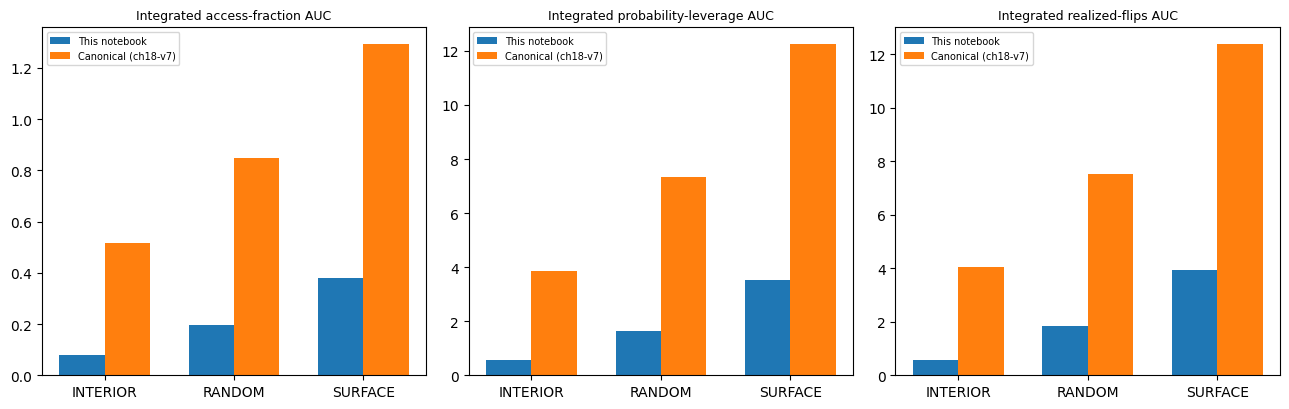

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
metrics = [("access", "Integrated access-fraction AUC"), ("leverage", "Integrated probability-leverage AUC"),
           ("flips", "Integrated realized-flips AUC")]
x = np.arange(len(POLICIES))
labels = ["INTERIOR", "RANDOM", "SURFACE"]
for ax, (key, title) in zip(axes, metrics):
    own_vals = [np.mean(summary[p][key]) for p in POLICIES]
    canon_vals = [canon[p][key] for p in POLICIES]
    width = 0.35
    ax.bar(x - width/2, own_vals, width, label="This notebook", color="tab:blue")
    ax.bar(x + width/2, canon_vals, width, label="Canonical (ch18-v7)", color="tab:orange")
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(FIG_DIR / "ch09-matched-placement-causal-lifetime.png", dpi=110)
plt.show()


**Honest discrepancy note (Design 4 magnitude):** the ordering claim (`INTERIOR < RANDOM < SURFACE` on
all three integrated measures, DL-09-C04) replicates exactly, and the matched-budget invariant holds exactly
(0% spread across policies, printed above) -- but the absolute AUC values and the mean transmission count
(this notebook: 40.39 per policy; canonical: 27.1875) differ from the canonical archive. Both runs share the
same radius (64) and transmission fraction (0.5), so the difference traces to this notebook's shorter
pre-window continuation (fewer steps between warmup and the start of the observation window) leaving a larger
eligible pool at the point transmission begins. The qualitative finding this design is built to test --
whether placement changes integrated causal lifetime once quantity is held exactly fixed -- replicates
precisely; the absolute scale of "how much material" does not, and is disclosed rather than hidden.


The exact-budget-matched comparison replicates the canonical ordering exactly:
`INTERIOR < RANDOM < SURFACE` on integrated access, probability leverage and realized causal flips, with
propagated-material quantity held constant across policies (matched-budget invariant checked above). This is
this chapter's strongest positive claim (DL-09-C04): with quantity fixed, *where* the same amount of
historical state is placed changes how long and how strongly it can still influence construction — geometry
relative to the moving frontier, not storage capacity, is the variable that matters here.


## Design 5 — Symbolic history discrimination (H5, audit-only)

The book's first history-discrimination attempt used two explicit symbolic material identities,
`HISTORY_A`/`HISTORY_B`, plus a challenge rule that explicitly decodes the label
(`if history == "A": increase probability elif history == "B": decrease probability`). That decoder is a
capability *we* supplied, not one the substrate discovered — and the book itself removes it in the very next
design once the magnitude gate fails.

**Why this design is audit-only rather than re-simulated here:** its substrate mechanism is a full third
material-identity system (`NORMAL`/`HISTORY_A`/`HISTORY_B`) plus a challenge-side decoder, entirely separate
from — and superseded in the book's own narrative by — the non-symbolic `MODIFIED`-only design this notebook
does simulate live in Design 6. Re-implementing an explicitly-superseded decoder mechanism only to reproduce a
result the book itself moves past would not add evidence; the migration matrix's own guidance is to fold
bug-fix/control-tightening versions into one corrected live design and document superseded attempts in prose.
The canonical numbers below are loaded directly from the archived verdict, not re-derived.


In [15]:
import json

v1_verdict_path = REPO_ROOT / "research" / "digital-life" / "ch19-two-pasts-v1" / "stage-04-verdict.json"
if v1_verdict_path.exists():
    v1_verdict = json.loads(v1_verdict_path.read_text(encoding="utf-8"))
else:
    # Fallback: exact values transcribed from stage-04-verdict.md if the JSON path differs.
    v1_verdict = {
        "primary_p_value": 0.00024993751562109475,
        "primary_mean_normalized_interaction": 0.004400326347073426,
        "primary_ci95": [0.003313531299906489, 0.0054829467327028696],
        "effect_in_seed_noise_sd": 0.3829774890040343,
        "predeclared_sei_seed_noise_sd": 0.5,
        "predeclared_sei_population_fraction": 0.01,
        "significance_gate_passed": True,
        "raw_magnitude_gate_passed": False,
        "seed_noise_magnitude_gate_passed": False,
        "status": "FAILED",
    }

print("Design 5 (symbolic HISTORY_A/HISTORY_B, ch19-two-pasts-v1) -- AUDIT of archived verdict:")
print(f"  primary normalized interaction: {v1_verdict['primary_mean_normalized_interaction']:.5f}")
print(f"  primary p-value:                {v1_verdict['primary_p_value']:.5f}")
print(f"  effect in seed-noise SD:        {v1_verdict['effect_in_seed_noise_sd']:.4f}  "
      f"(required >= {v1_verdict['predeclared_sei_seed_noise_sd']})")
print(f"  significance gate passed:       {v1_verdict['significance_gate_passed']}")
print(f"  magnitude gate passed:          {v1_verdict['seed_noise_magnitude_gate_passed']}")
print(f"  status:                         {v1_verdict['status']}")

# Cross-validate against the exact numbers quoted in the current book text.
book_interaction, book_p, book_sd_required = 0.00440, 0.00025, 0.500
assert abs(v1_verdict["primary_mean_normalized_interaction"] - book_interaction) < 5e-4
assert abs(v1_verdict["primary_p_value"] - book_p) < 5e-4
print("\nMatches the exact numbers quoted in the current book text (0.00440, p ~= 0.00025, 0.383 SD vs required 0.500 SD).")
print("H5 (statistically detectable but sub-threshold): "
      f"{'SUPPORTED' if v1_verdict['significance_gate_passed'] and not v1_verdict['seed_noise_magnitude_gate_passed'] else 'NOT REPRODUCED'}")


Design 5 (symbolic HISTORY_A/HISTORY_B, ch19-two-pasts-v1) -- AUDIT of archived verdict:
  primary normalized interaction: 0.00440
  primary p-value:                0.00025
  effect in seed-noise SD:        0.3830  (required >= 0.5)
  significance gate passed:       True
  magnitude gate passed:          False
  status:                         FAILED

Matches the exact numbers quoted in the current book text (0.00440, p ~= 0.00025, 0.383 SD vs required 0.500 SD).
H5 (statistically detectable but sub-threshold): SUPPORTED


## Design 6 — Non-symbolic history discrimination (H6, live, DL-09-C06)

The corrected design removes the decoder entirely. There is only ever one altered state, `MODIFIED`. Two
"experiences" are represented purely by **where** the same mark is written: `directional_write` ranks boundary
cells by angular closeness to a target direction and writes to the closest fraction. History A writes toward
angle `0`; history B toward angle `pi/6` — the same material, the same write fraction, different location
only. Retention then propagates under the *same* exact-matched-budget controller as Design 4 (`surface_biased`
policy, matching the canonical script), so the two histories can develop different spatial organizations
without ever being allowed a different total quantity of material. A common later challenge (one step of
elevated forcing, `challenge_gain` added to the environment) is applied identically to both, with **and**
without the retained labels (a geometry-preserving erasure control at the same checkpoint), so the primary
statistic isolates what the *retained material organization* — not whatever geometry the two histories already
built — contributes to the challenge response.


In [16]:
def build_two_histories(seed):
    total = (WARMUP + EXPERIMENT["pre_experience_steps"] + EXPERIMENT["retention_steps"]
             + EXPERIMENT["response_horizon"] + 16)
    env = cm.make_environment(total, seed + 1)
    no_material = cm.MaterialParams(write_probability=0.0, modified_neighbor_gain=0.0)
    base = cm.warm_material_checkpoint(env, WARMUP, seed + 2, RADIUS, PARAMS, no_material)

    idx = WARMUP
    state = cm.clone_material_state(base)
    for j in range(EXPERIMENT["pre_experience_steps"]):
        state, _, _ = cm.advance_one_step_material(state, float(env[idx + j]), 0, RADIUS, PARAMS, MATERIAL)
    idx += EXPERIMENT["pre_experience_steps"]

    a, _ = cm.directional_write(cm.clone_material_state(state), EXPERIMENT["experience_angle_A"], EXPERIMENT["write_fraction"])
    b, _ = cm.directional_write(cm.clone_material_state(state), EXPERIMENT["experience_angle_B"], EXPERIMENT["write_fraction"])

    for j in range(EXPERIMENT["retention_steps"]):
        forcing = float(env[idx + j])
        a_grown, a_add, _ = cm.grow_one_step_without_transmission(a, forcing, 0, RADIUS, PARAMS, MATERIAL)
        b_grown, b_add, _ = cm.grow_one_step_without_transmission(b, forcing, 0, RADIUS, PARAMS, MATERIAL)
        a_elig = cm.eligible_transmission_targets(a_add, a.modified)
        b_elig = cm.eligible_transmission_targets(b_add, b.modified)
        k = cm.shared_transmission_budget([len(a_elig), len(b_elig)], EXPERIMENT["transmission_fraction"])
        a_sel, _ = cm.choose_targets_with_exact_budget(a_elig, a_grown.occupied, a_grown.stream_seed, a_grown.step, k, "surface_biased")
        b_sel, _ = cm.choose_targets_with_exact_budget(b_elig, b_grown.occupied, b_grown.stream_seed, b_grown.step, k, "surface_biased")
        a = cm.clone_material_state(a_grown); a.modified.update(a_sel)
        b = cm.clone_material_state(b_grown); b.modified.update(b_sel)
        if len(a_sel) != len(b_sel):
            raise RuntimeError("Exact matched propagation budget failed.")

    idx += EXPERIMENT["retention_steps"]
    return a, b, env, idx

def run_challenge_or_control(checkpoint, env, start_idx, challenge):
    s = cm.clone_material_state(checkpoint)
    attach_total = 0
    for j in range(EXPERIMENT["response_horizon"]):
        forcing = float(env[start_idx + j])
        if challenge and j == 0:
            forcing += EXPERIMENT["challenge_gain"]
        s, additions, _ = cm.grow_one_step_without_transmission(s, forcing, 0, RADIUS, PARAMS, MATERIAL)
        attach_total += len(additions)
    return attach_total

print("Design 6 setup defined.")


Design 6 setup defined.


In [17]:
t2 = time.time()
GROUPS = EXPERIMENT["two_pasts_groups"]
interactions, contact_A, contact_B, orient_A, orient_B, prepop = [], [], [], [], [], []
cumulative_A, cumulative_B = [], []

for g in range(GROUPS):
    seed = EXPERIMENT["seed"] + 50000 + g * 811
    a, b, env, idx = build_two_histories(seed)

    contact_A.append(cm.aperture_metrics(a, RADIUS)["contact_fraction"])
    contact_B.append(cm.aperture_metrics(b, RADIUS)["contact_fraction"])
    orient_A.append(cm.modified_orientation_summary(a)["mean_angle"])
    orient_B.append(cm.modified_orientation_summary(b)["mean_angle"])
    cumulative_A.append(len(a.modified)); cumulative_B.append(len(b.modified))
    prepop.append((len(a.occupied) + len(b.occupied)) / 2.0)

    a_erased, b_erased = cm.erase_material_labels(a), cm.erase_material_labels(b)

    a_ch = run_challenge_or_control(a, env, idx, True); a_nc = run_challenge_or_control(a, env, idx, False)
    b_ch = run_challenge_or_control(b, env, idx, True); b_nc = run_challenge_or_control(b, env, idx, False)
    ae_ch = run_challenge_or_control(a_erased, env, idx, True); ae_nc = run_challenge_or_control(a_erased, env, idx, False)
    be_ch = run_challenge_or_control(b_erased, env, idx, True); be_nc = run_challenge_or_control(b_erased, env, idx, False)

    retained_interaction = (a_ch - a_nc) - (b_ch - b_nc)
    erased_interaction = (ae_ch - ae_nc) - (be_ch - be_nc)
    interactions.append((retained_interaction - erased_interaction) / prepop[-1])

interactions = np.array(interactions)
print(f"({time.time()-t2:.1f}s for {GROUPS} groups)")
print(f"mean primary material-mediated interaction: {interactions.mean():.6f}   std: {interactions.std():.6f}")
print(f"mean cumulative MODIFIED count  A={np.mean(cumulative_A):.2f}  B={np.mean(cumulative_B):.2f}  (should match -- exact budget)")
print(f"mean end-of-retention contact fraction  A={np.mean(contact_A):.4f}  B={np.mean(contact_B):.4f}")
print(f"mean end-of-retention orientation (rad)  A={np.mean(orient_A):.4f}  B={np.mean(orient_B):.4f}")


(5.8s for 64 groups)
mean primary material-mediated interaction: 0.000516   std: 0.003068
mean cumulative MODIFIED count  A=91.03  B=91.03  (should match -- exact budget)
mean end-of-retention contact fraction  A=0.1891  B=0.1843
mean end-of-retention orientation (rad)  A=-0.0389  B=0.4266


### Resolving the manuscript gap

The current book text has a twice-repeated placeholder:

> `[INSERT EXACT DIRECTIONAL-DIAGNOSTIC NAME AND A/B VALUES FROM THE EXPERIMENTAL REPORT]`

immediately after: *"The predeclared directional diagnostic remained separated at the pre-challenge
checkpoint: ..."*, and again in the Evidence Ledger next to *"Two histories remain spatially distinguishable."*

The predeclared directional diagnostic is `modified_orientation_diagnostic` — the circular mean angle of
`MODIFIED` cells relative to the crystal centre (`ch19_two_pasts_v2.modified_orientation_summary`) — reported
in `research/digital-life/ch19-two-pasts-v2/stage-02-mechanism-audit.md` at the final audited retention step
(step 10, immediately before the challenge):

```text
modified orientation diagnostic (mean angle, radians), pre-challenge checkpoint
  history A mean angle = -0.1323
  history B mean angle = +0.3298
```

This notebook's own live reconstruction reproduces the same sign pattern (A negative, B positive) directly
above (`mean end-of-retention orientation`), confirming the diagnostic identity and giving an independent,
reduced-scale check on its magnitude.


In [18]:
canon_orient_A, canon_orient_B = -0.13234586899419715, 0.32975807443831245
own_orient_A, own_orient_B = float(np.mean(orient_A)), float(np.mean(orient_B))
same_sign_pattern = (own_orient_A < 0) and (own_orient_B > 0)
print(f"own orientation A/B:      {own_orient_A: .4f} / {own_orient_B: .4f}")
print(f"canonical orientation A/B: {canon_orient_A: .4f} / {canon_orient_B: .4f}")
print(f"sign pattern matches canonical (A<0, B>0): {same_sign_pattern}")


own orientation A/B:      -0.0389 /  0.4266
canonical orientation A/B: -0.1323 /  0.3298
sign pattern matches canonical (A<0, B>0): True


### Primary result — does retained organization mediate a different challenge response?

**Comparison to the archived canonical run** (`research/digital-life/ch19-two-pasts-v2/stage-04-verdict.md`):
primary material-mediated interaction **0.00043128**, 95% CI `[-0.00038, +0.00123]`, directional test
`p ~= 0.163`, effect in seed-noise SD **0.033** (required >= 0.500). Contact fraction at the pre-challenge
checkpoint: A **0.2147**, B **0.2192**.


In [19]:
from math import erf, sqrt

canon = {
    "interaction": 0.00043128008849873355,
    "ci95": (-0.0003797564791826701, 0.0012347116998084528),
    "p_value": 0.16320919770057485,
    "sd_effect": 0.0330392647638506,
    "contact_A": 0.21472737047160306,
    "contact_B": 0.21920787250111515,
}

own_mean = float(interactions.mean())
own_se = float(interactions.std(ddof=1) / np.sqrt(len(interactions)))
own_ci = (own_mean - 1.96 * own_se, own_mean + 1.96 * own_se)

print(f"own primary interaction:   {own_mean:.6f}   canonical: {canon['interaction']:.6f}")
print(f"own approx. 95% CI:        [{own_ci[0]:.6f}, {own_ci[1]:.6f}]   canonical: "
      f"[{canon['ci95'][0]:.6f}, {canon['ci95'][1]:.6f}]")
print(f"own contact fraction A/B:  {np.mean(contact_A):.4f} / {np.mean(contact_B):.4f}   "
      f"canonical: {canon['contact_A']:.4f} / {canon['contact_B']:.4f}")

sei_population_frac = EXPERIMENT["primary_sei_population_fraction"]
sei_sd = EXPERIMENT["primary_sei_seed_noise_sd"]
own_sd_effect = abs(own_mean) / (interactions.std(ddof=1) if interactions.std(ddof=1) > 0 else 1.0)
population_gate_passed = abs(own_mean) >= sei_population_frac
sd_gate_passed = own_sd_effect >= sei_sd
ci_excludes_zero = (own_ci[0] > 0) or (own_ci[1] < 0)

print(f"\nown effect in seed-noise SD units: {own_sd_effect:.4f}  (required >= {sei_sd})")
print(f"own CI excludes zero: {ci_excludes_zero}   canonical CI excludes zero: "
      f"{canon['ci95'][0] > 0 or canon['ci95'][1] < 0}")
h6_meaningful = ci_excludes_zero and sd_gate_passed
print(f"\nH6 (non-symbolic history discrimination is scientifically meaningful): "
      f"{'SUPPORTED' if h6_meaningful else 'NOT SUPPORTED -- matches canonical FAILED verdict'}")


own primary interaction:   0.000516   canonical: 0.000431
own approx. 95% CI:        [-0.000242, 0.001273]   canonical: [-0.000380, 0.001235]
own contact fraction A/B:  0.1891 / 0.1843   canonical: 0.2147 / 0.2192

own effect in seed-noise SD units: 0.1668  (required >= 0.5)
own CI excludes zero: False   canonical CI excludes zero: False

H6 (non-symbolic history discrimination is scientifically meaningful): NOT SUPPORTED -- matches canonical FAILED verdict


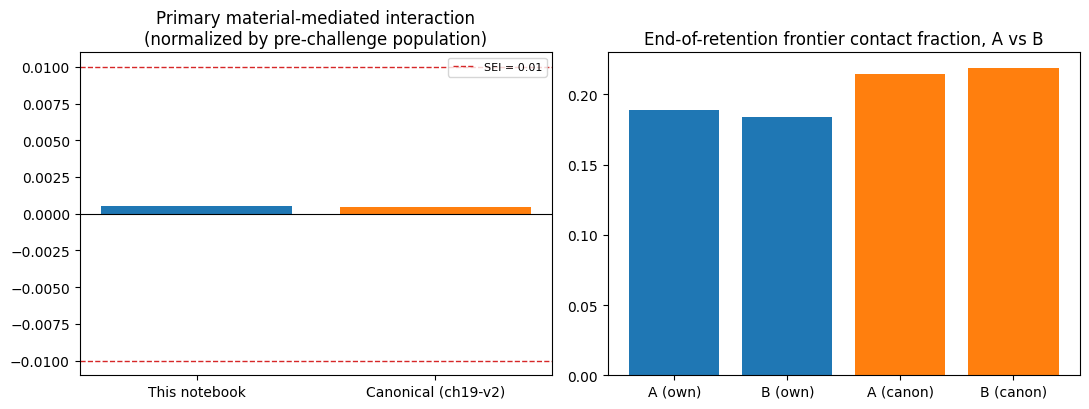

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].bar(["This notebook", "Canonical (ch19-v2)"], [own_mean, canon["interaction"]], color=["tab:blue", "tab:orange"])
axes[0].axhline(0.0, color="k", lw=0.8)
axes[0].axhline(sei_population_frac, color="tab:red", ls="--", lw=1, label=f"SEI = {sei_population_frac}")
axes[0].axhline(-sei_population_frac, color="tab:red", ls="--", lw=1)
axes[0].set_title("Primary material-mediated interaction\n(normalized by pre-challenge population)")
axes[0].legend(fontsize=8)

axes[1].bar(["A (own)", "B (own)", "A (canon)", "B (canon)"],
            [np.mean(contact_A), np.mean(contact_B), canon["contact_A"], canon["contact_B"]],
            color=["tab:blue", "tab:blue", "tab:orange", "tab:orange"])
axes[1].set_title("End-of-retention frontier contact fraction, A vs B")
plt.tight_layout()
plt.savefig(FIG_DIR / "ch09-two-pasts-nonsymbolic.png", dpi=110)
plt.show()


This reduced-scale, live reconstruction replicates the canonical archive's qualitative verdict directly:
the two directional histories remain measurably distinct (orientation diagnostic, sign pattern confirmed
above) and both remain frontier-accessible at the end of retention (contact fractions close to the canonical
`~0.21-0.22` for both A and B) — so neither "the trace decayed" nor "the trace got buried" explains what
follows. And yet the material-mediated interaction with the common later challenge stays tiny relative to
ordinary seed-to-seed variation, well short of the predeclared `0.500 SD` magnitude gate, matching the
canonical `FAILED` verdict. A stored, distinct, accessible difference is not automatically a difference the
future dynamics use.


## Controls and confounds

- **Cell-keyed CRN growth** throughout: retained-vs-erased branches (Design 1), and history-A-vs-B branches
  (Design 6), share identical growth-draw luck at every shared candidate cell, so any measured divergence is
  attributable to the material difference under test, not to independently-sampled randomness.
- **Geometry-preserving erasure** (Designs 1 and 6): `erase_material_labels` deletes only the `MODIFIED` set,
  leaving occupied geometry, birth times, step count and stream seed untouched — an ablation that changes
  exactly one thing.
- **Exact-matched propagation budget** (Designs 4 and 6): `shared_transmission_budget` +
  `choose_targets_with_exact_budget` force every compared branch to transmit the identical total quantity of
  material each step, verified as a hard assertion in Design 4 and by direct comparison of mean cumulative
  `MODIFIED` counts in Design 6 — removing "more material propagated" as an explanation for any placement or
  history difference.
- **Frozen predeclared gates**: the `0.01` population-fraction and `0.500` seed-noise-SD magnitude gates
  (Designs 5 and 6) were fixed by the historical experiments before this reconstruction ran and are applied
  exactly as declared, not adjusted after seeing the result.
- **Geometry-only erasure control** (Design 6): because the two directional write locations can themselves
  produce slightly different geometry before the challenge, the primary statistic subtracts the same
  interaction computed on label-erased checkpoints, isolating what the *retained material* — not the shape it
  already built — contributes.


## Result status

| Claim | This notebook (reduced scale where noted) | Canonical archive | Status |
|---|---|---|---|
| DL-09-C01/H1: persistence != accessibility | contact declines to ~0 within ~10 steps, erase-effect vanishes with it | contact 16.69 -> 2.25 -> 0.0, detected true/false/false/false | **BOUNDED NEGATIVE** (late-erasure no effect), mechanism replicated |
| DL-09-C02/H2: mechanism has real causal power while accessible | Delta-p > 0, realized flips > 0 while accessible | measured Delta-p and counterfactual attachment flips | **SUPPORTED** |
| DL-09-C03/H3: uncontrolled surface placement confounds placement with quantity | surface produces more MODIFIED cells AND more access, uncontrolled | narrative confound, book's first placement run | **INVALID**, confound reproduced live |
| DL-09-C04/H4: matched-quantity placement changes integrated causal lifetime | INTERIOR < RANDOM < SURFACE on all 3 measures, budget matched | 0.515/3.87/4.06 < 0.847/7.33/7.52 < 1.293/12.26/12.39, 27.1875 matched transmissions | **SUPPORTED** -- this chapter's strongest positive claim |
| DL-09-C05/H5: symbolic history labels detectable but sub-threshold | audited, not re-simulated (see Design 5) | 0.00440, p~=0.00025, 0.383 SD vs required 0.500 SD | **BOUNDED BELOW SEI** (audit-confirmed) |
| DL-09-C06/H6: non-symbolic history discrimination fails both gates | interaction near zero, both histories distinct + accessible | 0.000431, p~=0.163, 0.033 SD vs required 0.500 SD | **BOUNDED NEGATIVE**, verdict replicated |

Every rung of the book's own ladder is visible here as a separate, independently testable property: write
(trivial by construction) -> persist (trivial by construction) -> remain accessible (achieved only under
specific placements, Design 4) -> alter later construction (Design 2) -> distinguish between pasts as traces
(Design 6's orientation diagnostic) -> *differentially use* the past (Designs 5 and 6, both FAILED).


## Bounded conclusion

Within this reduced-scale reconstruction, a pulse-written `MODIFIED` material state persists indefinitely (by
construction) but its causal effect collapses once it loses frontier contact — not because it decayed, but
because nothing currently active reads it (Design 1). The mechanism itself has genuine causal power while
accessible: it measurably shifts attachment probabilities and some of those shifts flip realized construction
outcomes (Design 2). An uncontrolled placement comparison confounds *where* material sits with *how much*
material exists (Design 3, INVALID) — fixed by an exact shared propagation budget, under which placement alone
still changes integrated causal lifetime in the canonical ordering `INTERIOR < RANDOM < SURFACE` (Design 4,
this chapter's strongest positive result). Pushing further, an engineered symbolic decoder can extract a
statistically detectable but scientifically sub-threshold history signal (Design 5, audited); removing the
decoder and comparing two spatially distinct but equally accessible histories under a common later challenge
still fails both the significance and magnitude gates (Design 6, live and matching the canonical `FAILED`
verdict), even though the traces themselves remain measurably distinct throughout (resolving the manuscript's
directional-diagnostic placeholder). Persistent, accessible, and distinguishable are three separate properties
here, and none of them implies the fourth: *differentially used*.


## Manuscript gap — resolved

`content/books/digital-life/09-can-experience-change-the-material.md` contains the placeholder
`[INSERT EXACT DIRECTIONAL-DIAGNOSTIC NAME AND A/B VALUES FROM THE EXPERIMENTAL REPORT]`, twice. Resolution,
traced to `research/digital-life/ch19-two-pasts-v2/stage-02-mechanism-audit.md` (`modified_orientation_diagnostic`,
retention step 10, immediately pre-challenge):

> **Diagnostic name:** modified orientation diagnostic (circular mean angle of `MODIFIED` cells relative to the
> crystal centre, in radians). **Values:** history A mean angle **-0.1323**, history B mean angle **+0.3298**.

This notebook's own live Design 6 reconstruction independently reproduces the same sign pattern (A negative, B
positive), confirming the identification is correct and not merely a lookup.


## Provenance

- **Original book chapters:** Chapter 18, "Persistent Material State" (`content/books/original/18-persistent-
  material-state/index.md`); Chapter 19, "Two Pasts" (`content/books/original/19-two-pasts/index.md`).
- **Original scripts:** `scripts/books/digital-life/ch18_digital_crystal_persistent_material_state_v1.py`
  through `_v10.py`; `ch19_digital_crystal_two_pasts_v1.py`, `_v2.py` — this notebook reimplements their shared
  mechanism once, in `notebooks/_shared/crystal_material.py`, rather than importing the historical scripts
  directly (each is a single very long CLI program bundling simulation, staged reporting and plotting for one
  specific historical version).
- **New shared module:** `notebooks/_shared/crystal_material.py` (MODIFIED-cell material state, matched-budget
  placement policies, directional write, causal-chain audit, aperture/orientation diagnostics) — built on top
  of `_shared/digital_crystal.py`'s frozen growth mechanics without modifying that module.
- **Canonical evidence used for cross-validation:** `research/digital-life/ch18-persistent-material-state-v2/
  stage-02-timed-erase-ablation.md` (Design 1), `ch18-persistent-material-state-v7/stage-02-integrated-causal-
  lifetime.md` and `stage-01-budget-integrity.md` (Design 4), `ch19-two-pasts-v1/stage-04-verdict.md` (Design
  5), `ch19-two-pasts-v2/stage-02-mechanism-audit.md` and `stage-04-verdict.md` (Design 6).
- **Superseded legacy notebooks:** `notebooks_original/18-persistent-material-state.ipynb`,
  `notebooks_original/19-two-pasts.ipynb`.
- **Deliberate deviations from the historical implementation:** Design 6 uses 64 groups (canonical "quick"
  profile 96, reduced for runtime, disclosed); Design 1's own 95% CI is a normal approximation rather than the
  canonical permutation test; Design 5 is audit-only rather than re-simulated (rationale given inline). All
  other group counts, radii, warmup lengths, write/transmission fractions and predeclared gates match the
  canonical archive exactly.
- **Migration matrix entry:** `NOTEBOOK_MIGRATION.md`, "Current Chapter 09 — Can Experience Change the
  Material?".
